# LDA Topic Modelling 

This notebook visualises the topic created using LDA topic modelling.

In [3]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from gensim.corpora import Dictionary
from gensim.models import LdaModel

In [4]:
DATA_FILE = Path("../out/dcit_courses_skills.jsonl")

df = pd.read_json(DATA_FILE, lines=True)

df_expanded = df.explode("thematic_areas").rename(
    columns={"thematic_areas": "thematic_area"}
)

def normalize_multiword_skills(skills):
    if not isinstance(skills, list):
        return []
    return [str(s).strip().replace(" ", "_") for s in skills if str(s).strip()]

df_expanded["skills"] = df_expanded["skills"].apply(normalize_multiword_skills)

cs_df = df_expanded[df_expanded["thematic_area"] == "computer_science"].copy()
it_df = df_expanded[df_expanded["thematic_area"] == "information_technology"].copy()

def clean_tokens(tokens):
    return [t for t in tokens if t not in {"computer_science", "information_technology"}]

cs_texts = [clean_tokens(t) for t in cs_df["skills"].tolist()]
it_texts = [clean_tokens(t) for t in it_df["skills"].tolist()]

In [5]:
def train_lda(texts, num_topics, label, no_below=1, no_above=0.8):
    dictionary = Dictionary(texts)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)
    corpus = [dictionary.doc2bow(doc) for doc in texts]

    print(f"[{label}] Training LDA with k={num_topics}...")
    print(f"  Documents : {len(texts)}")
    print(f"  Vocab size: {len(dictionary)}")

    model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        random_state=42,
        passes=10,
        iterations=100,
    )

    print(f"\n[{label}] Top 10 words per topic:")
    for topic_num, topic_words in model.print_topics(num_words=10):
        print(f"  Topic {topic_num}: {topic_words}")

    return model, dictionary, corpus


def plot_top_words(model, num_topics, label, top_n=10):
    fig, axes = plt.subplots(
        (num_topics + 1) // 2, 2,
        figsize=(14, num_topics * 1.8),
        constrained_layout=True,
    )
    axes = axes.flatten()

    for topic_idx in range(num_topics):
        top_words = model.show_topic(topic_idx, topn=top_n)
        words = [w for w, _ in top_words]
        probs = [p for _, p in top_words]
        axes[topic_idx].barh(words[::-1], probs[::-1])
        axes[topic_idx].set_title(f"Topic {topic_idx}", fontsize=10)
        axes[topic_idx].tick_params(axis="y", labelsize=8)

    for idx in range(num_topics, len(axes)):
        axes[idx].set_visible(False)

    plt.suptitle(f"{label} — Course LDA Topics (k={num_topics})", fontsize=13)
    plt.show()

[Computer Science] Training LDA with k=18...
  Documents : 37
  Vocab size: 1159

[Computer Science] Top 10 words per topic:
  Topic 0: 0.008*"cognitive_model" + 0.008*"interaction_design" + 0.008*"teamwork" + 0.008*"online_communities" + 0.008*"social_medium" + 0.008*"presentations" + 0.004*"parallel_processing" + 0.004*"communication_system" + 0.004*"route_protocol" + 0.004*"application_level"
  Topic 1: 0.011*"management_system" + 0.011*"sql" + 0.011*"database_management_system" + 0.006*"programming" + 0.006*"algorithms" + 0.006*"collision_detection" + 0.006*"virtual_reality" + 0.006*"distribution_functions" + 0.006*"time_series" + 0.006*"model_building"
  Topic 2: 0.023*"develop_software" + 0.023*"project_management" + 0.023*"software_system" + 0.016*"milestones" + 0.016*"apply_research" + 0.016*"software_documentation" + 0.016*"timelines" + 0.016*"design_solutions" + 0.016*"project_plan" + 0.016*"problem_solve"
  Topic 3: 0.001*"operations" + 0.001*"mobile_applications" + 0.001*"m

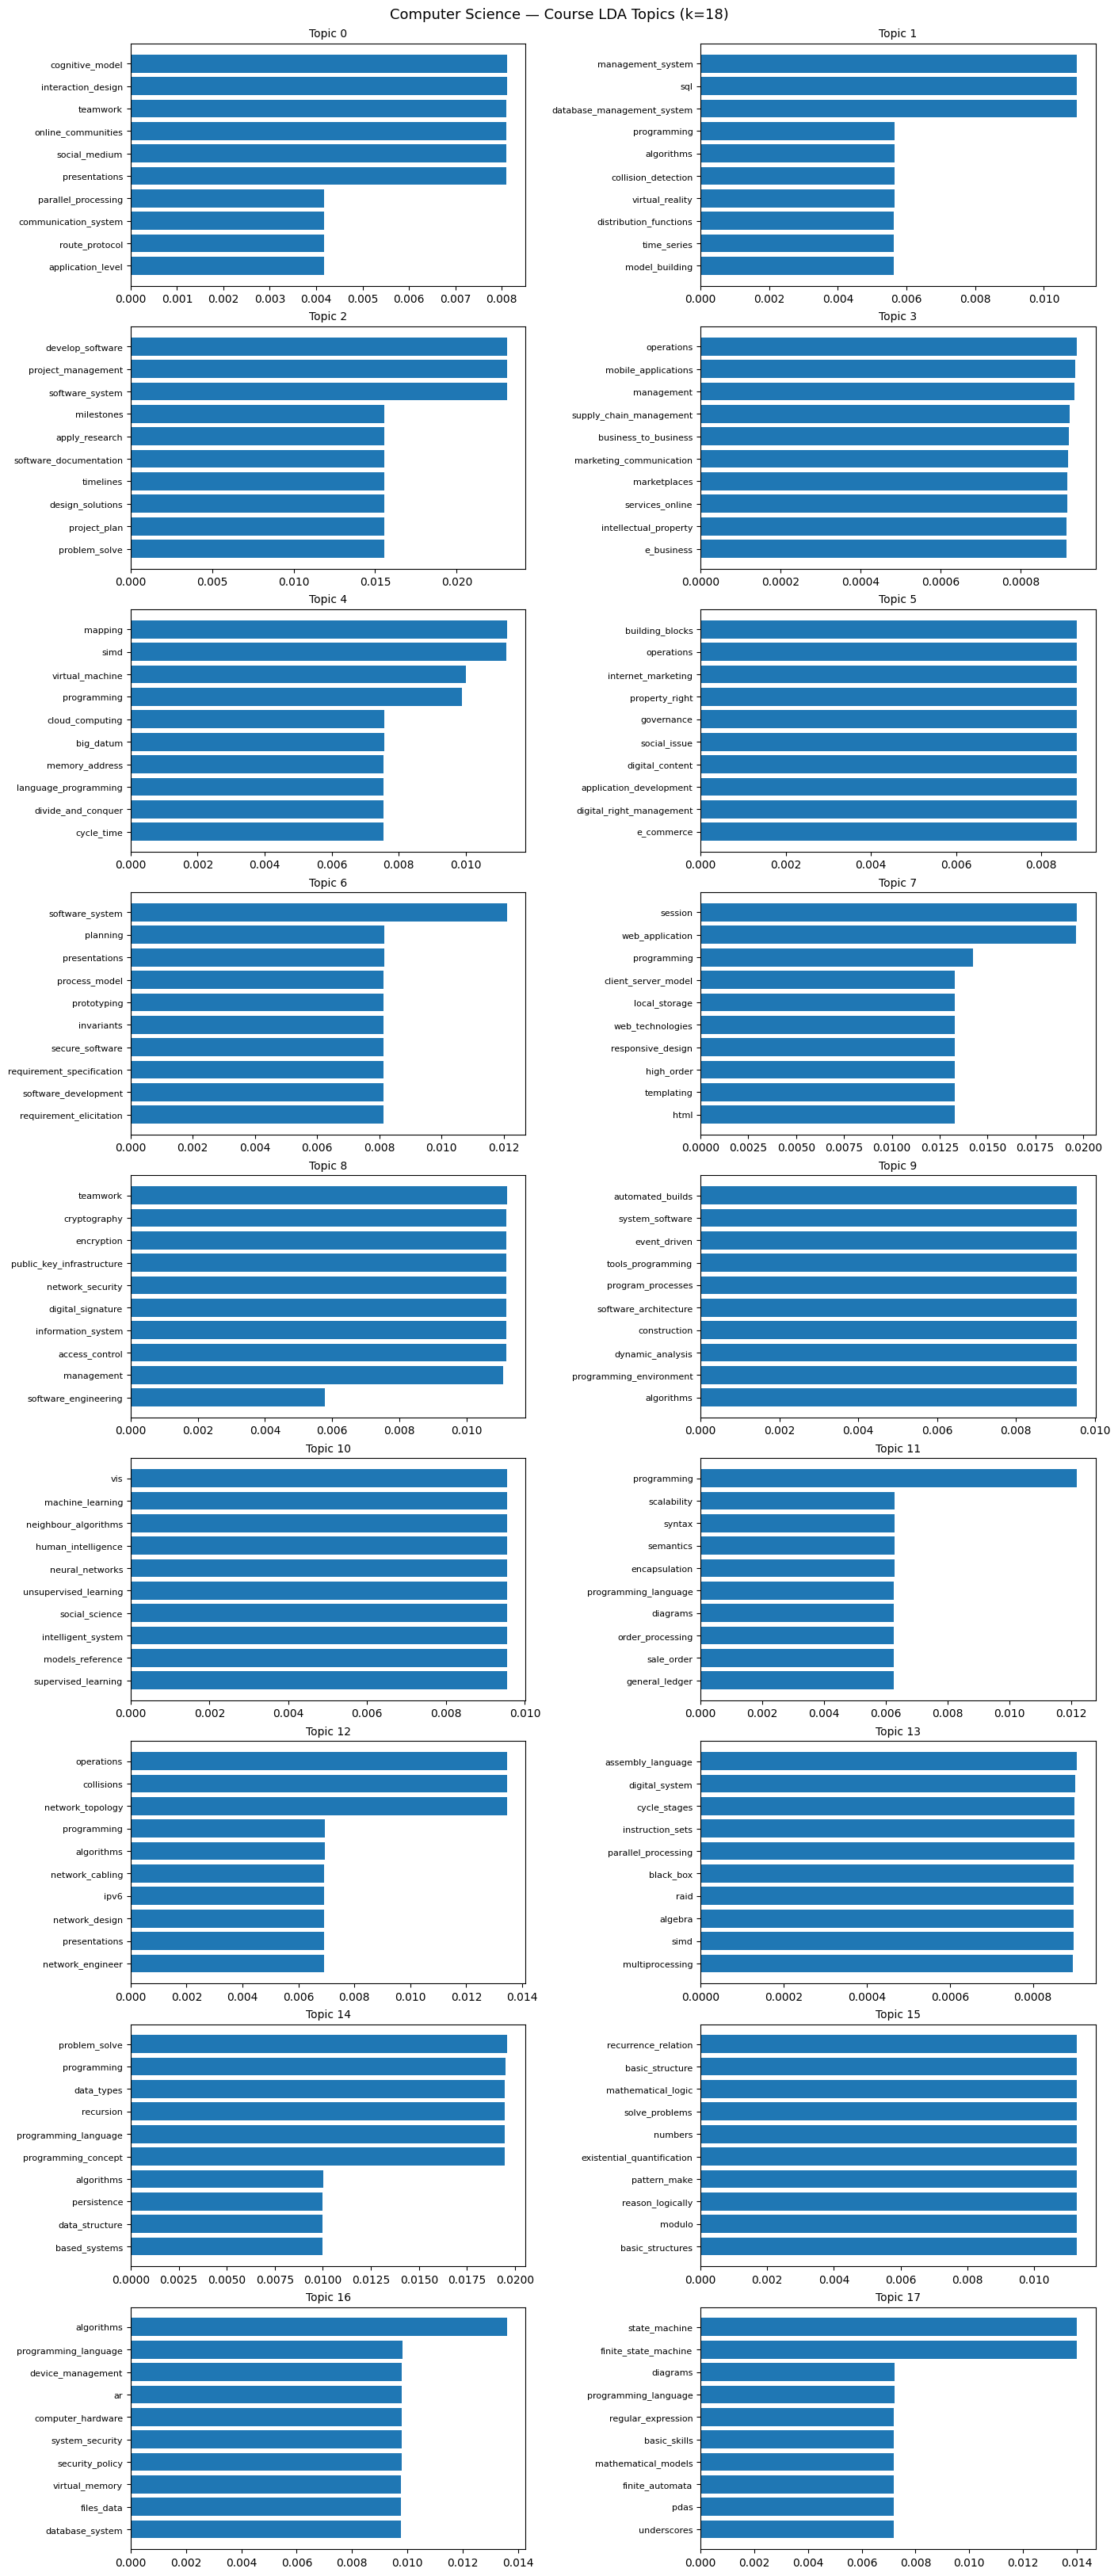

In [6]:
cs_model, cs_dictionary, cs_corpus = train_lda(cs_texts, 18, "Computer Science")
plot_top_words(cs_model, 18, "Computer Science")

[Information Technology] Training LDA with k=18...
  Documents : 31
  Vocab size: 1039

[Information Technology] Top 10 words per topic:
  Topic 0: 0.011*"simulations" + 0.011*"calibration" + 0.011*"random_number" + 0.011*"system_design" + 0.011*"real_data" + 0.011*"discrete_event" + 0.011*"forecasting" + 0.011*"distribution_functions" + 0.011*"discrete_event_simulation" + 0.011*"model_building"
  Topic 1: 0.009*"motion_capture" + 0.009*"integration" + 0.009*"inverse_kinematic" + 0.009*"human_computer_interaction" + 0.009*"data_structures" + 0.009*"technical_documentation" + 0.009*"rigid_body" + 0.009*"game_physics" + 0.009*"software_configuration_management" + 0.009*"programming_language"
  Topic 2: 0.011*"programming" + 0.011*"teamwork" + 0.011*"web_application" + 0.011*"session" + 0.011*"information_system" + 0.006*"algorithms" + 0.006*"generally_accepted_principles" + 0.006*"reconnaissance" + 0.006*"password_authentication" + 0.006*"digital_asset"
  Topic 3: 0.008*"computer_system"

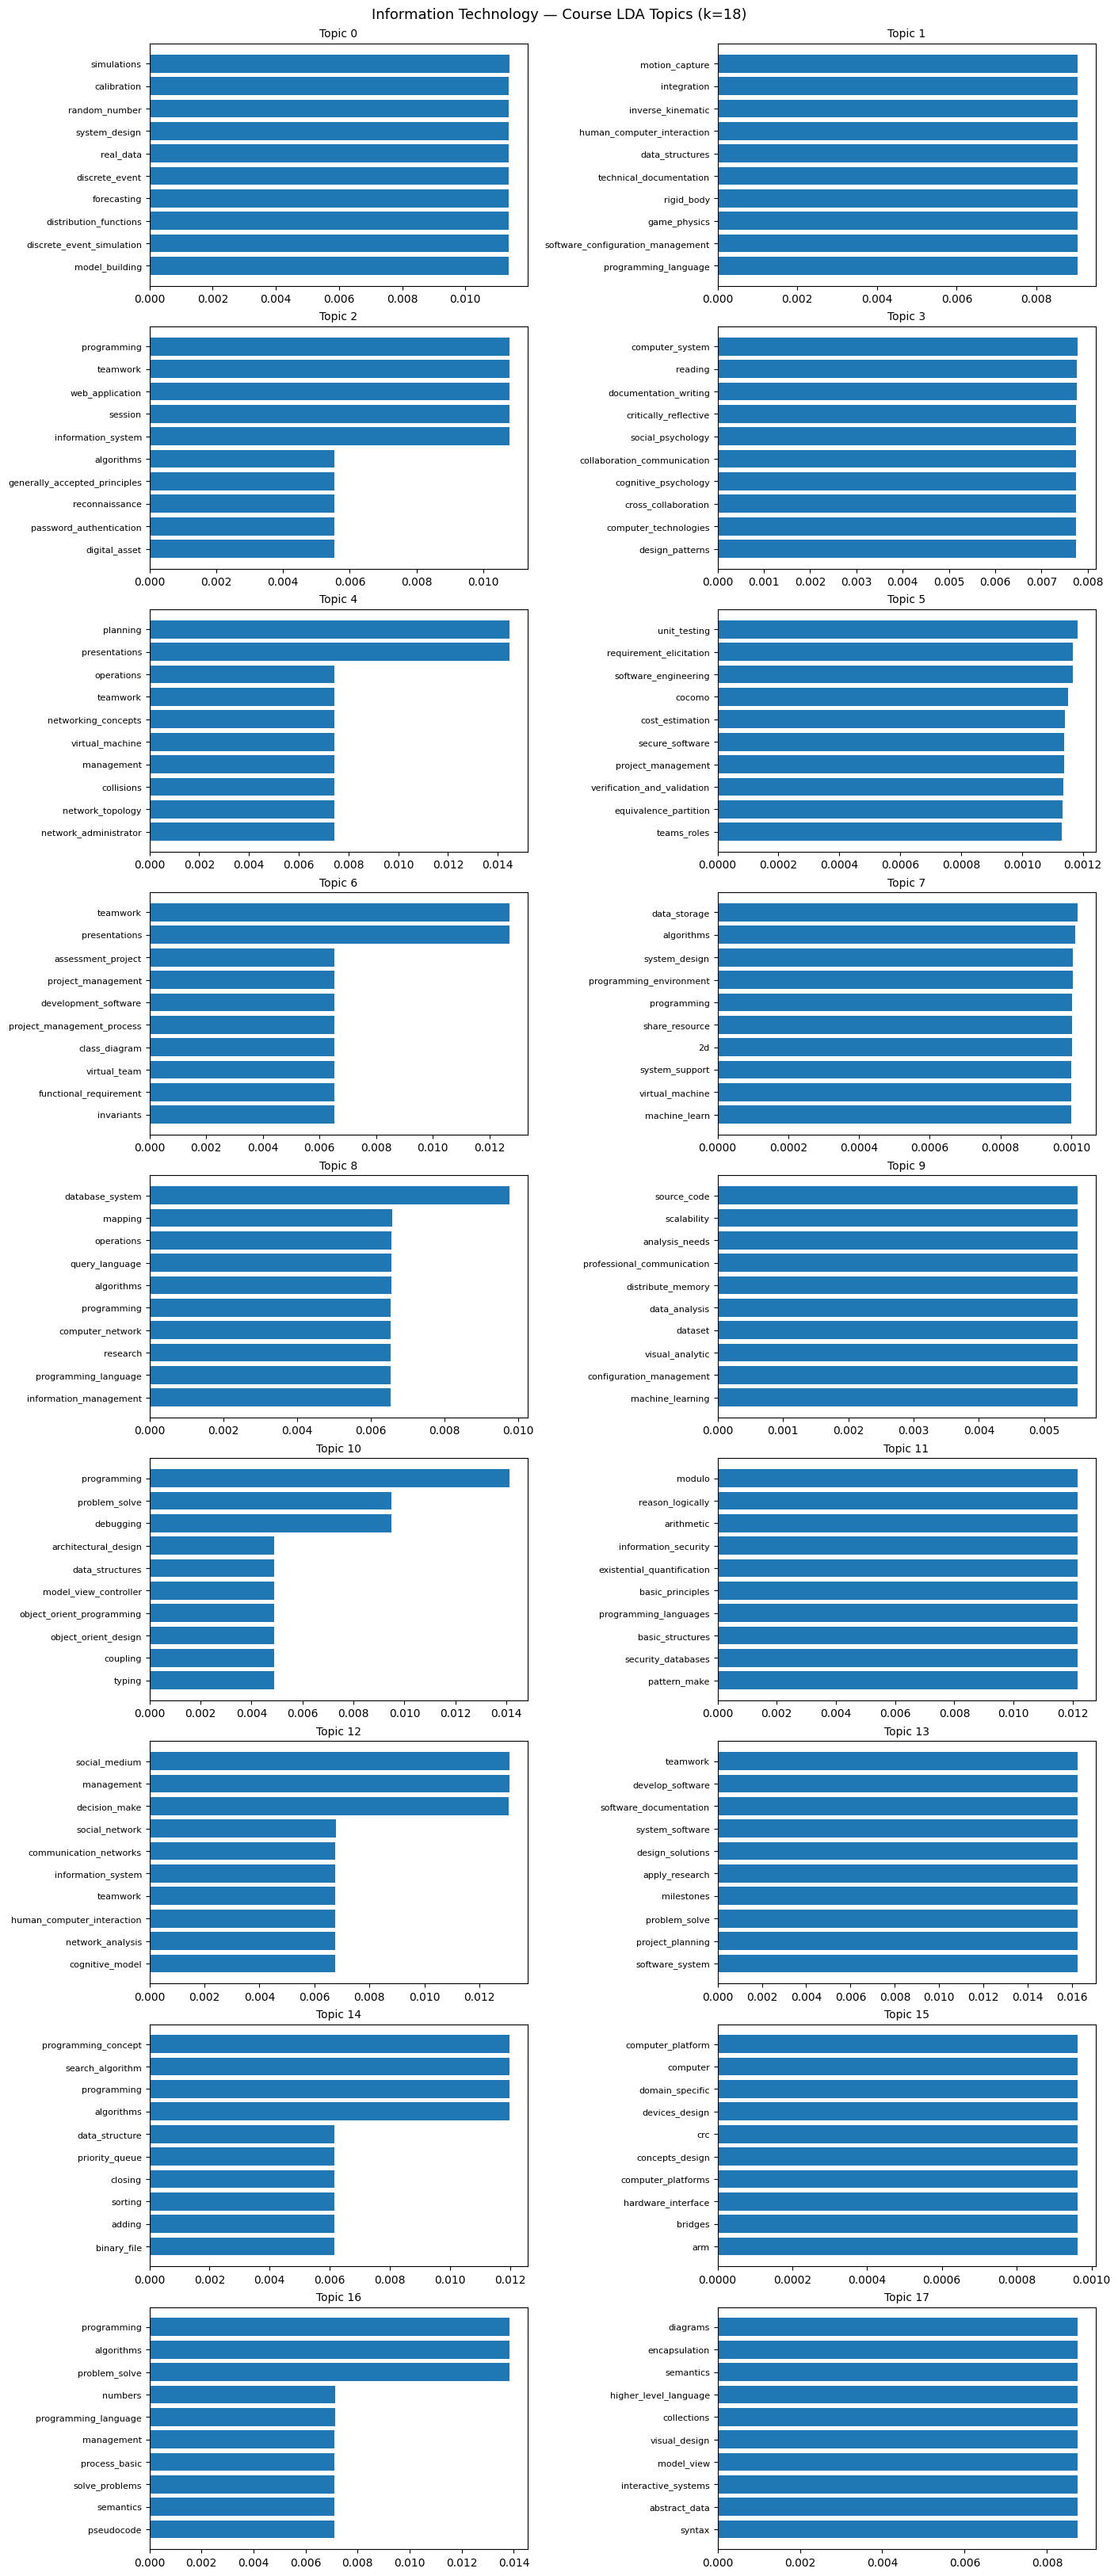

In [7]:
it_model, it_dictionary, it_corpus = train_lda(it_texts, 18, "Information Technology")
plot_top_words(it_model, 18, "Information Technology")